<div style="text-align:center; font-weight:bold; font-size:34px; margin-top:40px;">
    Notebook I — Climate Regime
<div>

<p style="text-align:center; font-size:20px; color:#444; margin-top:5px;">
    PyAEZ Version 3.0 &nbsp; | &nbsp; 2026
</p>

<hr style="margin-top:25px; margin-bottom:25px;">

<p style="text-align:center; font-size:18px;">
    This module analyzes climatic conditions and compiles essential agro‑climatic indicators. 
    These indicators characterize the climate profile of the study area for each grid cell, 
    serving as a foundation for subsequent agro‑ecological assessments.  
    Key inputs for this module include climate datasets, geospatial layers, and terrain information.
</p>

<p style="text-align:center; font-size:16px; color:#555;">
    Prepared by <strong>Dario Spiller</strong><br>
    Geospatial Unit — Land and Water Division (NSL)<br>
    Food and Agriculture Organization of the United Nations (FAO HQ)
</p>

<hr style="margin-top:25px; margin-bottom:25px;">

In [1]:
'''import supporting libraries'''
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr
import rasterio
from shapely.geometry import box
from rasterio.features import geometry_mask
import pyproj
import pickle
from pathlib import Path

try:
    from osgeo import gdal
except:
    import gdal
import sys

os.environ['PROJ_LIB'] = '/opt/conda/share/proj'
gdal.UseExceptions() 
np.round_ = np.round
os.environ['PROJ_LIB'] = pyproj.datadir.get_data_dir()

# --- BOOTSTRAP: add project root to sys.path ---
project_root = Path().resolve().parent       # tutorials → project root
sys.path.append(str(project_root))

from pyaez import pre_proc_utilities

In [2]:
# Setting the correct working folder
pre_proc_utilities.set_working_folder()

Notebook directory : D:\Documenti_Lavoro\FAO\Contratto FAO 2025 Sept-Dec\Python-AEZ-FAO\PyAEZ3.0\module1
Project root set to: D:\Documenti_Lavoro\FAO\Contratto FAO 2025 Sept-Dec\Python-AEZ-FAO\PyAEZ3.0


In [3]:
# Import pyaez modules used when creating the AEZ object
from pyaez import ClimateRegime
from pyaez.UtilitiesCalc import saveRaster, classifyFinalYield

# Now load the pickle
with open('./data_input/input_module1/clim_reg.pkl', 'rb') as f:
    clim_reg = pickle.load(f)

C:\Users\dario\anaconda3\envs\PyAEZ-CAVApy\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
C:\Users\dario\anaconda3\envs\PyAEZ-CAVApy\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


# Thermal Climate
The Thermal Climate function calculates and classifies latitudinal thermal climate, which will be used later in Module 2 for the assessment of potential crops and land utilization types (LUT) presence in each grid cell.

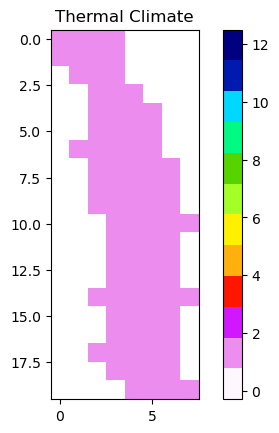

In [4]:
tclimate = clim_reg.getThermalClimate()

'''save and visualize result'''
fig = plt.figure()
plt.imshow(tclimate, cmap=plt.get_cmap('gist_ncar_r', 12),vmin=-0.3,vmax=12.5)
plt.title('Thermal Climate')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_ThermalClimate_{clim_reg.year}.png",bbox_inches ="tight",dpi=300) #Save as PNG image
plt.show()

saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_ThermalClimate_{clim_reg.year}.tif',tclimate) #Save as GeoTIFF raster

# Thermal Zone
The thermal zone is classified based on actual temperature which reflects on the temperature regimes of major thermal climates

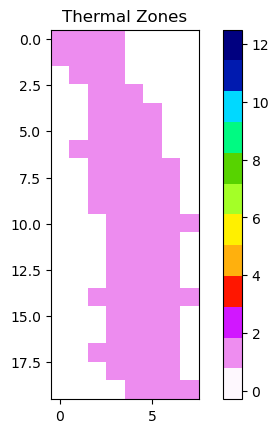

In [5]:
tzone = clim_reg.getThermalZone()

'''save and visualize result'''
fig = plt.figure()
plt.imshow(tzone, cmap=plt.get_cmap('gist_ncar_r', 12),vmin=-0.3,vmax=12.5)
plt.title('Thermal Zones')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_ThermalZone_{clim_reg.year}.png",bbox_inches ="tight",dpi=300) #Save as PNG image
plt.show()

saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_ThermalZone_{clim_reg.year}.tif',tzone) #Save as GeoTIFF raster

# Thermal Length of Growing Period (LGP)
The thermal length of growing period (LGPt) is defined as the number of days in a year during which the daily mean temperature (Ta) is conductive to crop growth and development. PyAEZ utilizes the AEZ three standard temperature thresholds for LGPt:
- Periods with Ta>0°C (LGPt0)
- Periods with Ta>5°C (LGPt5) – the period conductive to plant growth and development
- Periods, and Ta>10°C (LGPt10) – a proxy for the period of low risks for late and early frost occurrences and termed ‘frost-free period’

In [6]:
lgpt0 = clim_reg.getThermalLGP0()
lgpt5 = clim_reg.getThermalLGP5()
lgpt10 = clim_reg.getThermalLGP10()

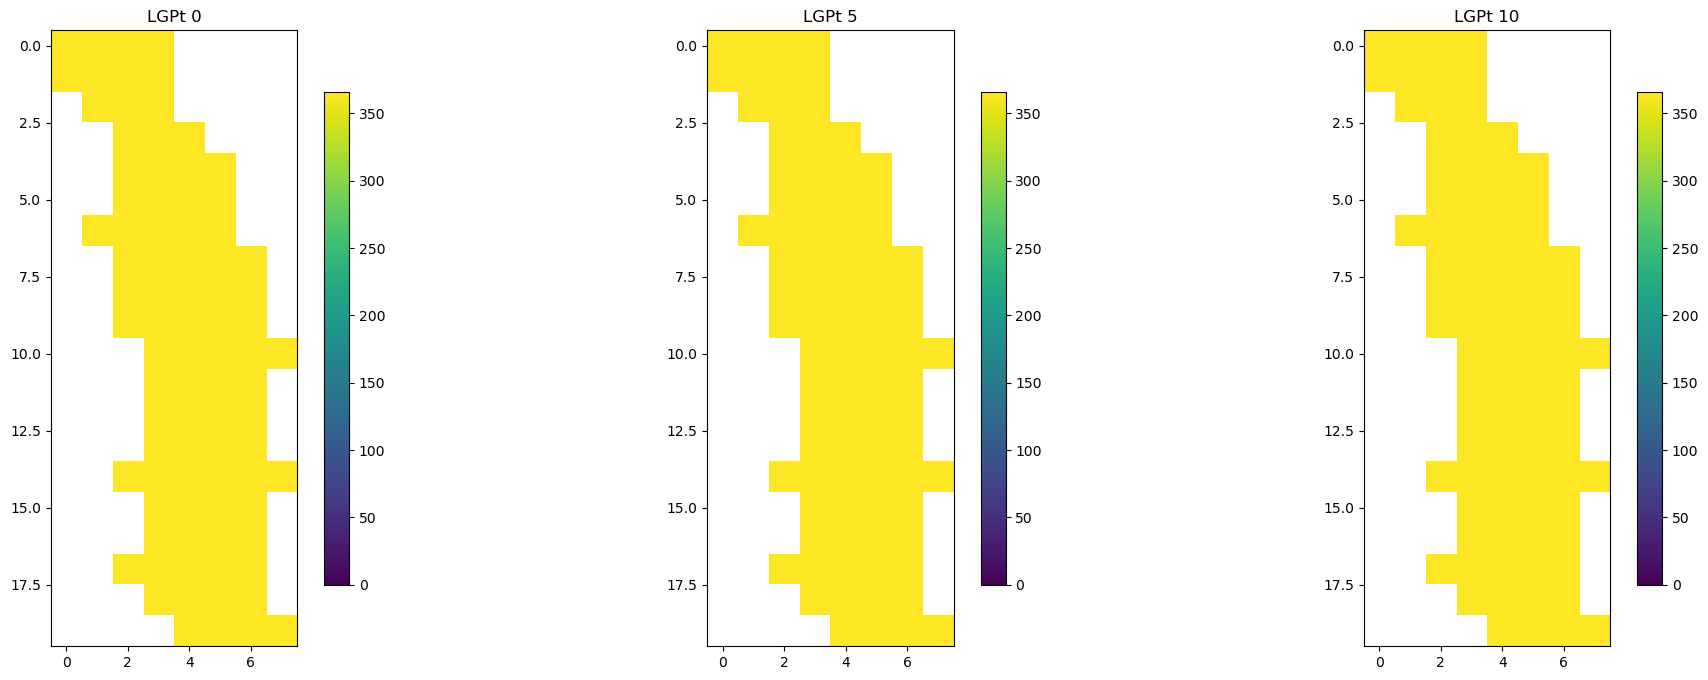

In [7]:
'''save and visualize result'''
#======================
plt.figure(1, figsize=(24, 8))
plt.subplot(1, 3, 1)
plt.imshow(lgpt0,vmin=0,vmax=366)
plt.title('LGPt 0')
plt.colorbar(shrink=0.8)
#----------------------
plt.subplot(1, 3, 2)
plt.imshow(lgpt5, vmin=0, vmax=366)
plt.title('LGPt 5')
plt.colorbar(shrink=0.8)
#----------------------
plt.subplot(1, 3, 3)
plt.imshow(lgpt10, vmin=0, vmax=366)
plt.title('LGPt 10')
plt.colorbar(shrink=0.8)
#----------------------
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_ThermalLGPs_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
#======================

saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_LGPt0_{clim_reg.year}.tif', lgpt0)
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_LGPt5_{clim_reg.year}.tif', lgpt5)
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_LGPt10_{clim_reg.year}.tif', lgpt10)


# Temperature Sum

In [8]:
tsum0 = clim_reg.getTemperatureSum0()
tsum5 = clim_reg.getTemperatureSum5()
tsum10 = clim_reg.getTemperatureSum10()

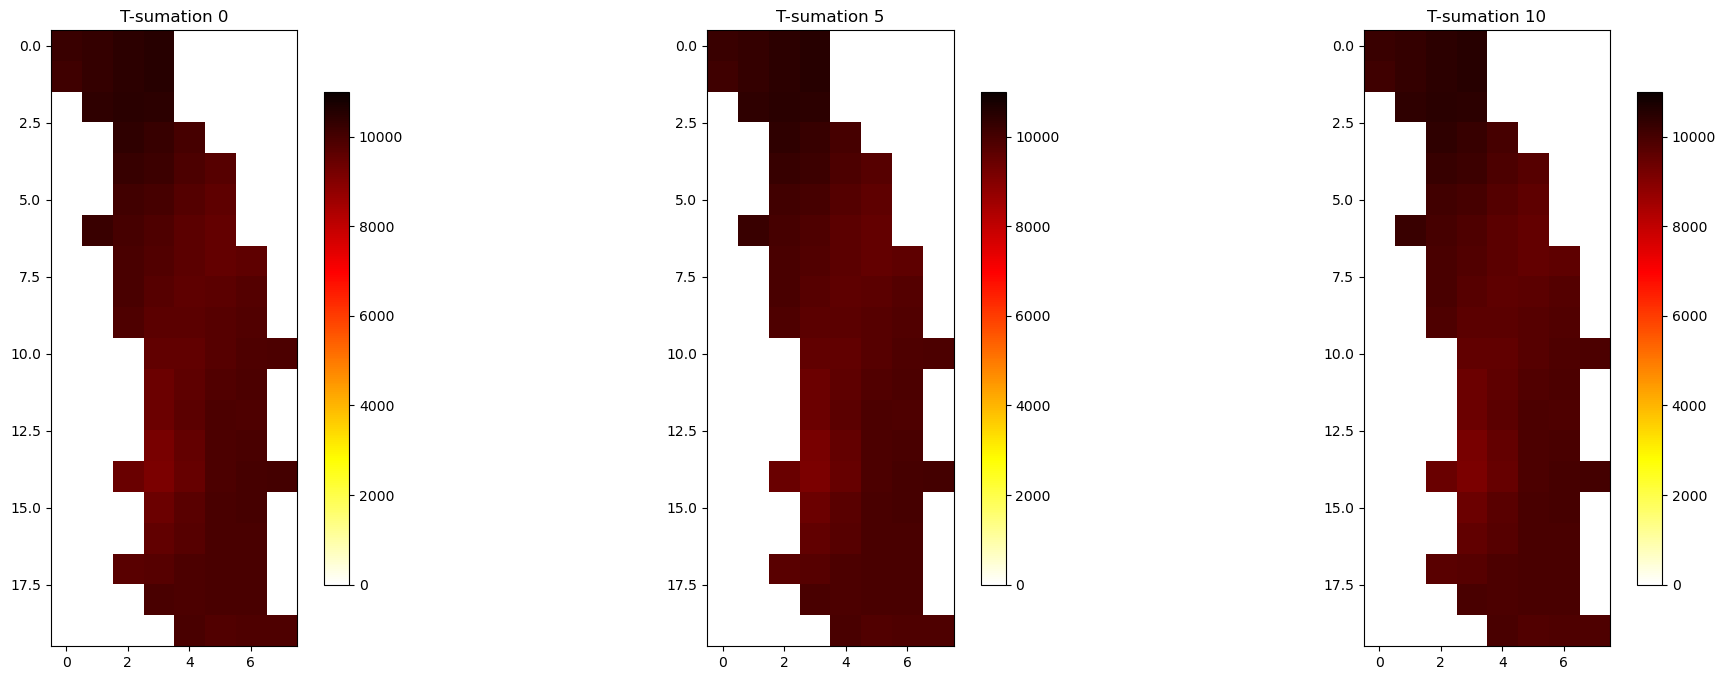

In [9]:
'''save and visualize result'''
#======================
plt.figure(1, figsize=(24, 8))
plt.subplot(1, 3, 1)
plt.imshow(tsum0, cmap='hot_r', vmin=0, vmax=11000)
plt.title('T-sumation 0')
plt.colorbar(shrink=0.8)
#----------------------
plt.subplot(1, 3, 2)
plt.imshow(tsum5, cmap='hot_r', vmin=0, vmax=11000)
plt.title('T-sumation 5')
plt.colorbar(shrink=0.8)
#----------------------
plt.subplot(1, 3, 3)
plt.imshow(tsum10, cmap='hot_r', vmin=0, vmax=11000)
plt.title('T-sumation 10')
plt.colorbar(shrink=0.8)
#----------------------
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_Tsum_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
#======================

saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_tsum0_{clim_reg.year}.tif', tsum0)
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_tsum5_{clim_reg.year}.tif', tsum5)
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_tsum10_{clim_reg.year}.tif', tsum10)


# Temperature Profile

In [10]:
tprofile = clim_reg.getTemperatureProfile()

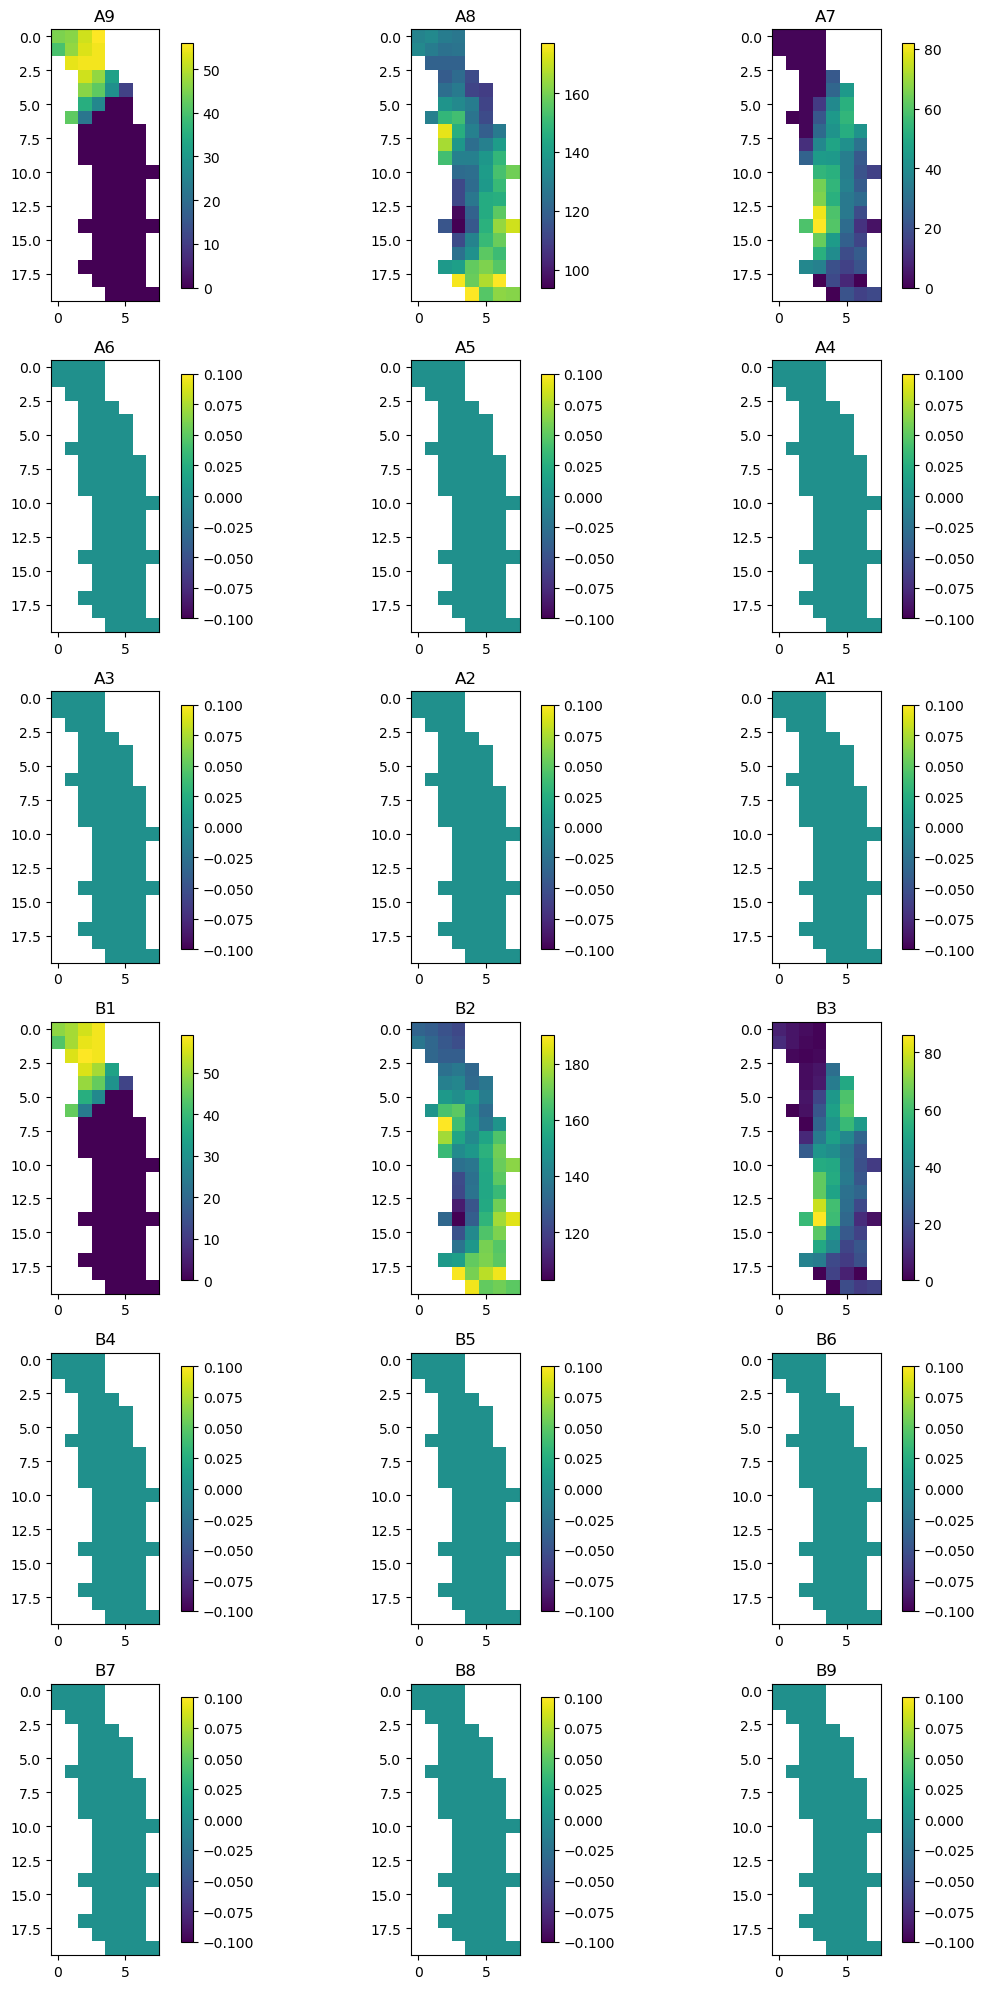

In [11]:
'''save and visualize result'''

tile_list = ['A9', 'A8', 'A7', 'A6', 'A5', 'A4', 'A3', 'A2',
             'A1', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9']

fig = plt.figure(figsize=(12, 20))
for i1 in range(1, 19):
    plt.subplot(6, 3, i1)
    plt.imshow(tprofile[i1-1])
    plt.title(tile_list[i1-1])
    plt.colorbar(shrink=0.9)
plt.tight_layout()

plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_Tprofiles_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()

for i1 in range(18):
    saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_TProfile_' + tile_list[i1] + '.tif', tprofile[i1])
    #obj_utilities.saveRaster('./sample_data/input/LAO_Admin.tif', './sample_data/output/NB1/TProfile_' + tile_list[i1] +'.tif', tprofile[i1])


# Length of Growing Periods (LGPs)

In [12]:
lgp = clim_reg.getLGP()
lgp_class = clim_reg.getLGPClassified(lgp)
lgp_equv = clim_reg.getLGPEquivalent()

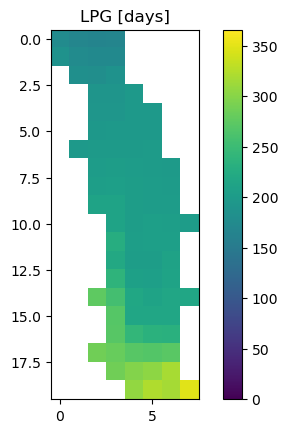

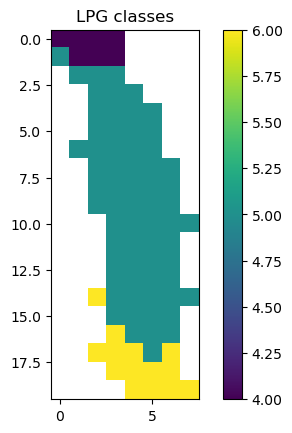

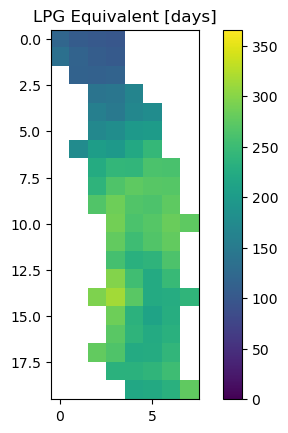

In [13]:
'''save and visualize result'''

plt.imshow(lgp, cmap='viridis', vmin=0, vmax=366)
plt.title('LPG [days]')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_LGP_{clim_reg.year}.png", bbox_inches="tight", dpi=300)
plt.show()

'''save and visualize result'''

plt.imshow(lgp_class, cmap='viridis') #, vmin=0, vmax=366
plt.title('LPG classes')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_LGP_classes_{clim_reg.year}.png", bbox_inches="tight", dpi=300)
plt.show()


plt.imshow(lgp_equv, cmap='viridis', vmin=0, vmax=366)
plt.title('LPG Equivalent [days]')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_LGP_Equv_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()

saveRaster(clim_reg.ref_raster, rf'./data_output/NB1/{clim_reg.country_name}_LGP_{clim_reg.year}.tif', lgp)
saveRaster(clim_reg.ref_raster, rf'./data_output/NB1/{clim_reg.country_name}_LGPEquivalent_{clim_reg.year}.tif', lgp_equv)


# Multi Cropping Zone
Multiple cropping zones classification is an additional agro-climatic indicator, which relates to the possibility of cultivating multiple sequential crops under rain-fed and irrigated conditions.

In [14]:
multi_crop = clim_reg.getMultiCroppingZones(tclimate, lgp, lgpt5, lgpt10, tsum0, tsum10)
multi_crop_rainfed = multi_crop[0]  # for rainfed conditions
multi_crop_irr = multi_crop[1]  # for irrigated conditions


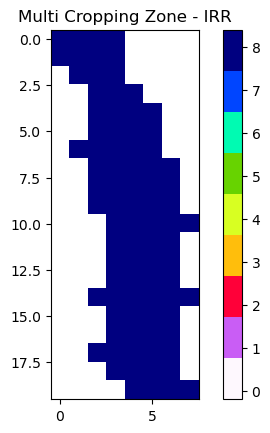

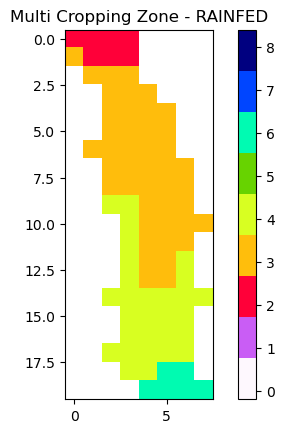

In [15]:
'''save and visualize result'''

plt.imshow(multi_crop_irr, cmap=plt.get_cmap('gist_ncar_r', 9), vmin=-0.2, vmax=8.4)
plt.title('Multi Cropping Zone - IRR')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_multicrop_irr_{clim_reg.year}.png", bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, rf'./data_output/NB1/{clim_reg.country_name}_multicrop_irr_{clim_reg.year}.tif', multi_crop_irr)


plt.imshow(multi_crop_rainfed,cmap=plt.get_cmap('gist_ncar_r', 9), vmin=-0.2, vmax=8.4)
plt.title('Multi Cropping Zone - RAINFED')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_multicrop_rain_{clim_reg.year}.png",bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, rf'./data_output/NB1/{clim_reg.country_name}_multicrop_rain_{clim_reg.year}.tif', multi_crop_rainfed)


# Air Frost Index and Permafrost Evaluation
Occurrence of continuous or discontinuous permafrost conditions are used in the suitability assessment. Permafrost areas are characterized by sub-soil at or below the freezing point for two or more years. In this section, PyAEZ utilizes the air frost index (FI) which is used to characterize climate-derived permafrost condition into 4 classes: 
1) Continuous permafrost
2) Discontinuous permafrost 
3) Sporadic permafrost
4) No permafrost

In [16]:
permafrost_eval = clim_reg.AirFrostIndexandPermafrostEvaluation()
frost_index = permafrost_eval[0]
permafrost = permafrost_eval[1]

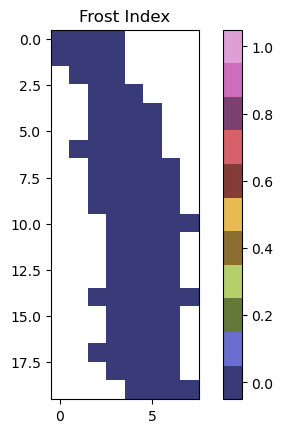

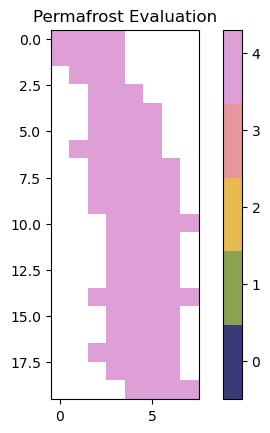

In [17]:
'''save and visualize result'''

plt.imshow(frost_index, cmap=plt.get_cmap(
    'tab20b', 11), vmin=-0.05, vmax=1.05)
plt.title('Frost Index')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_frost_index_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, rf'./data_output/NB1/{clim_reg.country_name}_frost_index_{clim_reg.year}.tif', frost_index)



plt.imshow(permafrost, cmap=plt.get_cmap(
    'tab20b', 5), vmin=-0.5, vmax=4.3)
plt.title('Permafrost Evaluation')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_permafrost_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, rf'./data_output/NB1/{clim_reg.country_name}_permafrost_{clim_reg.year}.tif', permafrost)


# Fallow period requirement
Fallow is an agricultural technique that consists of not sowing the arable land during one or more growing seasons. In AEZ framework, the fallow factors have been established by main crop groups and environmental conditions. The crop groups include cereals, legumes, roots and tubers, and a miscellaneous group consisting of long-term annuals/perennials. The fallow factors are expressed as percentage of time during the fallow-cropping cycle the land must be under fallow. PyAEZ determines the fallow requirements using Thermal Zones.

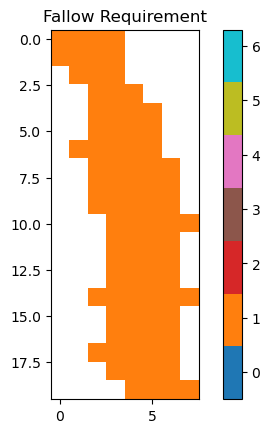

In [18]:
tzone_fallow = clim_reg.TZoneFallowRequirement(tzone)

'''save and visualize result'''
fig = plt.figure()
plt.imshow(tzone_fallow, cmap=plt.get_cmap('tab10', 7), vmin=-0.5, vmax=6.3)
plt.title('Fallow Requirement')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_fallow_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, rf'./data_output/NB1/{clim_reg.country_name}_fallow_{clim_reg.year}.tif', tzone_fallow)


# Agro-ecological zones classification
The agro-ecological zones (AEZ) methodology provides a framework for establishing a spatial inventory of land resources compiled from global/national environmental data sets and assembled to quantify multiple spatial characteristics required for the assessments of land productivity under location-specific agro-ecological conditions.

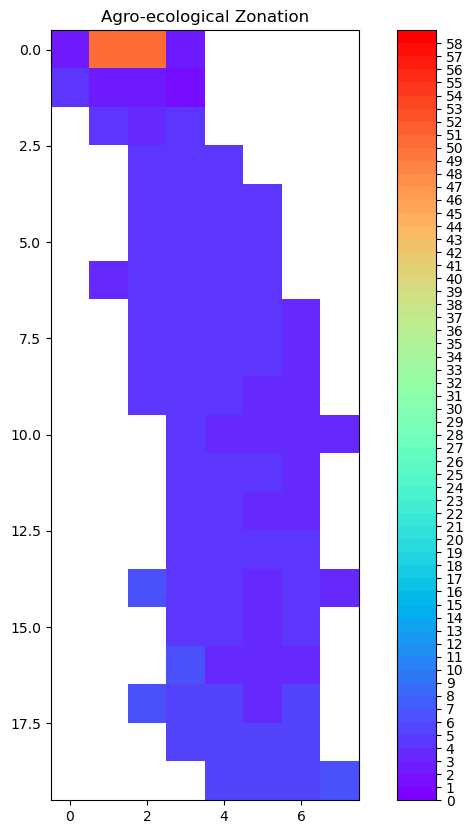

In [19]:
soil_terrain_lulc = gdal.Open(rf'./data_input/{clim_reg.country_name}_lulc_resampled_clipped.tif').ReadAsArray()

aez = clim_reg.AEZClassification(
    tclimate, lgp, lgp_equv, lgpt5, soil_terrain_lulc, permafrost)

# now visualizing result
fig = plt.figure(figsize= (10,10))
plt.imshow(aez, cmap=plt.get_cmap('rainbow', 59), vmin=0, vmax=59)
plt.title('Agro-ecological Zonation')
plt.colorbar(ticks = np.arange(0,59,1))
plt.savefig(rf"./data_output/NB1/{clim_reg.country_name}_aez_{clim_reg.year}.png", bbox_inches="tight", dpi=300)
plt.show()

saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_aez_{clim_reg.year}.tif', aez)


# Annual Temperature Amplitude 
The annual temperture amplitude provides information of how continental a region is. Calculated by the difference between the hottest month and the coldest month of the year.

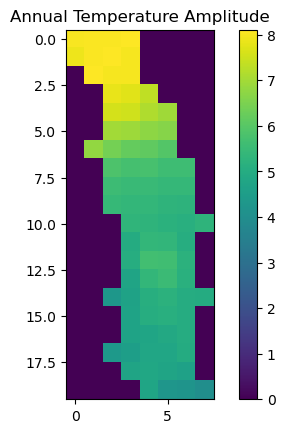

In [20]:
td2 = clim_reg.getAnnualTemperatureAmplitude()

# now visualizing result
fig = plt.figure()
plt.imshow(td2, cmap='viridis', vmin=np.nanmin(td2), vmax=np.nanmax(td2))
plt.title('Annual Temperature Amplitude')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_td2_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_td2_{clim_reg.year}.tif', td2)

# Reference Annual Total Potential Evapotranspiration (ET0) 
The total summation of potential evapotranspiration for a year.

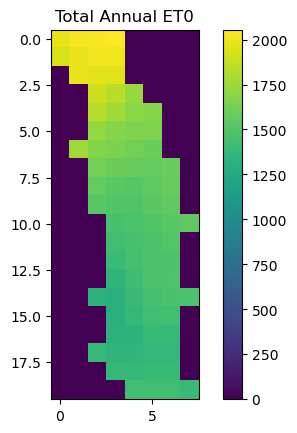

In [21]:
et0 = clim_reg.getETODaily()

# now visualizing result
fig = plt.figure()
plt.imshow(et0, cmap='viridis', vmin=np.nanmin(et0), vmax=np.nanmax(et0))
plt.title('Total Annual ET0')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_et0_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_et0_{clim_reg.year}.tif', et0)

# Annual Moisture Availability Index (P/ET0)
P/ET0 compares the incoming precipitation to the evaporative demand of a reference crop.
Values below 100 = water deficit
Values above 100 = precipitation exceeds evaporative demand

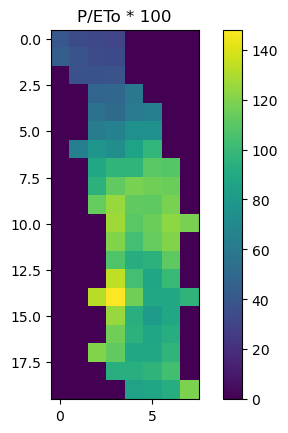

In [22]:
p_et0 = clim_reg.getAnnualMoistureAvailabilityIndex()

# now visualizing result
fig = plt.figure()
plt.imshow(p_et0, cmap='viridis', vmin=np.nanmin(p_et0), vmax=np.nanmax(p_et0))
plt.title('P/ETo * 100')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_p_eto_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_p_et0_{clim_reg.year}.tif', p_et0)

# Annual total reference actual evapotranspiration (ETa)
The total summation of actual evapotranspiration of the reference crop for a year.

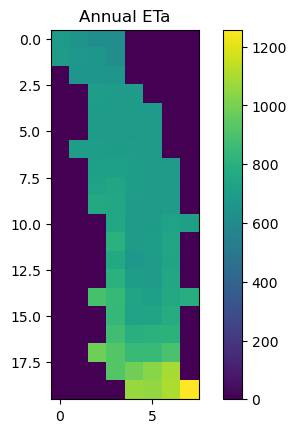

In [23]:
eta = clim_reg.getETaDaily()

# now visualizing result
fig = plt.figure()
plt.imshow(eta, cmap='viridis', vmin=np.nanmin(eta), vmax=np.nanmax(eta))
plt.title('Annual ETa')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_eta_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_eta_{clim_reg.year}.tif', eta)

# Annual total reference water deficit (Wde)
The difference the annual potential and actual evapotranspiration (Wde = ETm - ETa) to measure the discrepency the evaporative demand of a well-watered vegetation and the actual moisture supply under rainfed condition.
This indicator comes from reference water balance but does not consider actual soil condition.

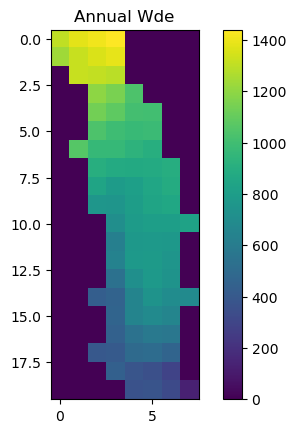

In [24]:
wde = clim_reg.getReferenceAnnualWaterDeficit()

# now visualizing result
fig = plt.figure()
plt.imshow(wde, cmap='viridis', vmin=np.nanmin(wde), vmax=np.nanmax(wde))
plt.title('Annual Wde')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_wde_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_wde_{clim_reg.year}.tif', wde)

# Net Primary Productivity (NPP)
NPP estimates a polynomial function of incoming solar radiation and soil moisture at the rhizosphere.
Calculated based on daily ETa to serve as a climate related indicator of rainfed biological activity.
Different routines are established for irrigated and rainfed conditions.

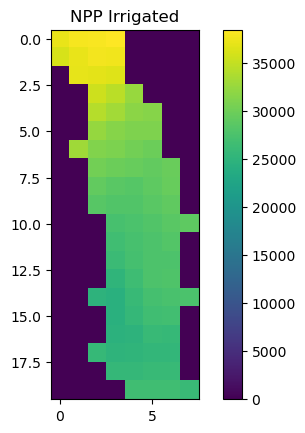

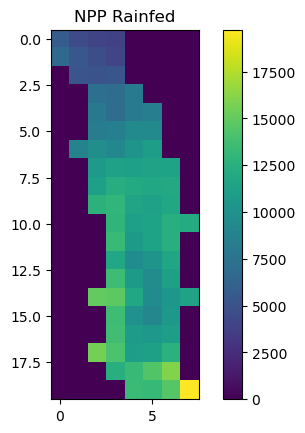

In [25]:
nppi = clim_reg.getNPP('I')
nppr = clim_reg.getNPP('R')

# now visualizing result
fig = plt.figure()
plt.imshow(nppi, cmap='viridis', vmin=np.nanmin(nppi), vmax=np.nanmax(nppi))
plt.title('NPP Irrigated')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_nppi_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_nppi_{clim_reg.year}.tif', nppi)

# now visualizing result
fig = plt.figure()
plt.imshow(nppr, cmap='viridis', vmin=np.nanmin(nppr), vmax=np.nanmax(nppr))
plt.title('NPP Rainfed')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_nppr_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_nppr_{clim_reg.year}.tif', nppr)

# LGP of the Longest Componenets
In reality, LGP cycles can be more than one. This agro-climatic indicators detects all possible LGP cycles and produces the number of growing days with the longest LGP cycle as output.

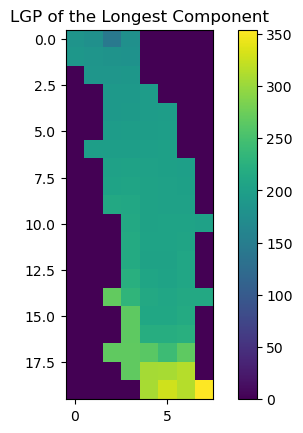

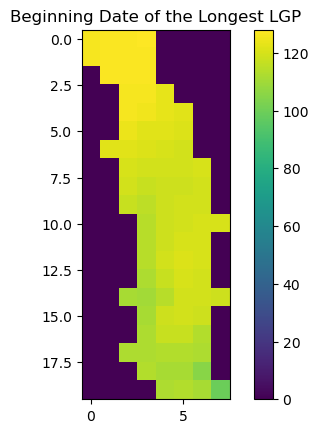

In [26]:
lgp_longest, lgp_beginday = clim_reg.getLGPlongest()

# now visualizing result
fig = plt.figure()
plt.imshow(lgp_longest, cmap='viridis', vmin=np.nanmin(lgp_longest), vmax=np.nanmax(lgp_longest))
plt.title('LGP of the Longest Component')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_lgplongest_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_lgplongest_{clim_reg.year}.tif', lgp_longest)

# now visualizing result
fig = plt.figure()
plt.imshow(lgp_beginday, cmap='viridis', vmin=np.nanmin(lgp_beginday), vmax=np.nanmax(lgp_beginday))
plt.title('Beginning Date of the Longest LGP')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_lgb_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_lgb_{clim_reg.year}.tif', lgp_beginday)


# Beginning Date of the hibernation period
This indicator produces the starting date of the hibernation period

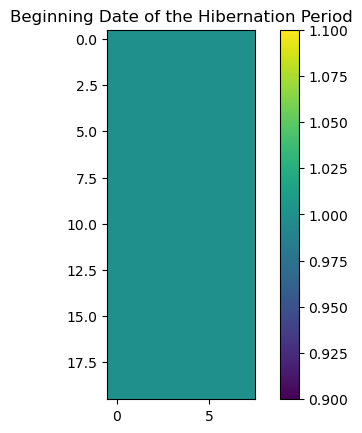

In [27]:
lgh_b = clim_reg.getBeginningDateofHibernationPeriod()

# now visualizing result
fig = plt.figure()
plt.imshow(lgh_b, cmap='viridis', vmin=np.min(lgh_b), vmax=np.nanmax(lgh_b))
plt.title('Beginning Date of the Hibernation Period')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_lgh_b_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_lgh_b_{clim_reg.year}.tif', lgh_b)

# Length of the Dormancy period
This indicator produces the starting date of the hibernation period, one of the useful component for the crops which needs dormnacy period.

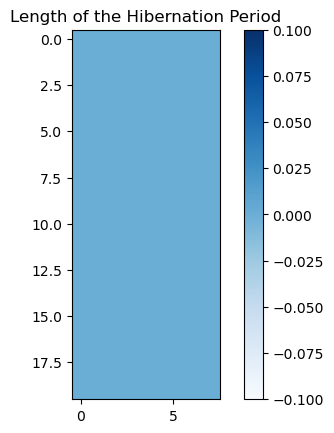

In [28]:
lgh = clim_reg.getHibernationPeriodLength()

# now visualizing result
fig = plt.figure()
plt.imshow(lgh, cmap='Blues', vmin=np.min(lgh), vmax=np.nanmax(lgh))
plt.title('Length of the Hibernation Period')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{clim_reg.country_name}_lgh_{clim_reg.year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(clim_reg.ref_raster, f'./data_output/NB1/{clim_reg.country_name}_lgh_{clim_reg.year}.tif', lgh)

<hr>

# END OF MODULE 1: CLIMATE REGIME

<hr>